In [25]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

data=pd.read_csv("data/clean_data.csv")
data

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,total_score,average
0,female,group B,bachelor's degree,standard,none,218,72.666667
1,female,group C,some college,standard,completed,247,82.333333
2,female,group B,master's degree,standard,none,278,92.666667
3,male,group A,associate's degree,free/reduced,none,148,49.333333
4,male,group C,some college,standard,none,229,76.333333
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,282,94.000000
996,male,group C,high school,free/reduced,none,172,57.333333
997,female,group C,high school,free/reduced,completed,195,65.000000
998,female,group D,some college,standard,completed,223,74.333333


In [26]:
X = data.drop(columns=['average'],axis=1)
y=data['average']

In [27]:
print("Categories in 'gender' variable:     ",end=" " )
print(data['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(data['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(data['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(data['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(data['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [28]:
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
    ]
)
X = preprocessor.fit_transform(X)

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler(with_mean=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)
X_train = scaler.fit_transform(X_train)  
X_test  = scaler.transform(X_test)      

In [40]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}


model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 12.1157
- Mean Absolute Error: 9.8383
- R2 Score: 0.2299
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 12.8682
- Mean Absolute Error: 10.2897
- R2 Score: 0.2287


Lasso
Model performance for Training set
- Root Mean Squared Error: 12.4288
- Mean Absolute Error: 9.9879
- R2 Score: 0.1896
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 13.3618
- Mean Absolute Error: 10.6379
- R2 Score: 0.1684


Ridge
Model performance for Training set
- Root Mean Squared Error: 12.1157
- Mean Absolute Error: 9.8378
- R2 Score: 0.2299
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 12.8685
- Mean Absolute Error: 10.2898
- R2 Score: 0.2287


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 11.6234
- Mean Absolute Error: 9.2688
- R2 Score: 0.2912
-------------

In [41]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.228739
2,Ridge,0.228712
8,AdaBoost Regressor,0.176536
1,Lasso,0.168446
3,K-Neighbors Regressor,0.075359
5,Random Forest Regressor,0.053287
7,CatBoosting Regressor,-0.008251
6,XGBRegressor,-0.056867
4,Decision Tree,-0.098896


 Accuracy of the model is 22.87


Text(0, 0.5, 'Predicted')

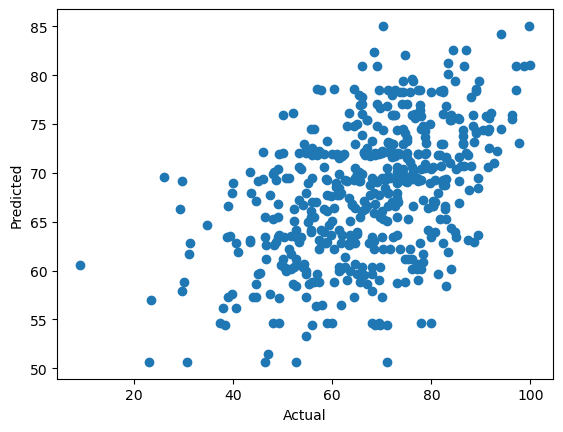

In [42]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

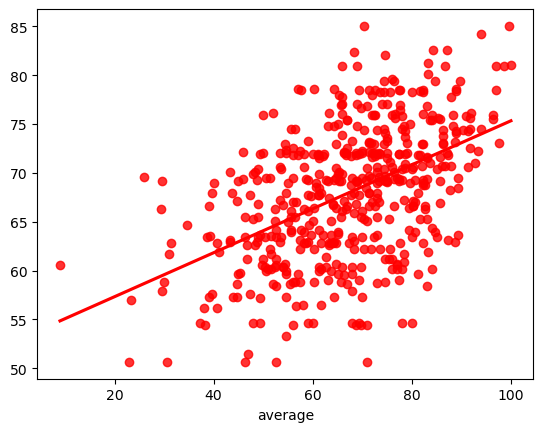

In [43]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');